# Seed Brightness Trend Analysis and Visualization

This notebook analyzes brightness information of seeds based on their relative positions in the image and estimates the brightness trend of seeds.

In [45]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import glob
from scipy import ndimage
from sklearn.decomposition import PCA
import seaborn as sns
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# Configuration
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# Data directory
data_dir = Path('/Users/ponywen/projects/ienf_q/data')
print(f"Data directory: {data_dir}")

Data directory: /Users/ponywen/projects/ienf_q/data


In [46]:
# Load sample进行分析
def load_sample(sample_dir):
    """Load sample images"""
    image_path = sample_dir / 'image.png'
    annotation_path = sample_dir / 'annotation.png'
    mask_path = sample_dir / 'mask.png'
    
    image = np.array(cv2.imread(str(image_path)))[:,:,1]
    
    annotation = np.array(cv2.imread(str(annotation_path), cv2.IMREAD_GRAYSCALE))
    mask = np.array(cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE))
    
    return image, annotation, mask

# Select sample
sample_dir = data_dir / 'S1585-2_a'
image, annotation, mask = load_sample(sample_dir)

print(f"Image shape: {image.shape}")
print(f"Annotation shape: {annotation.shape}")
print(f"Mask形状: {mask.shape}")
print(f"图片Brightness range: [{image.min()}, {image.max()}]")

Image shape: (2867, 5632)
Annotation shape: (2867, 5632)
Mask形状: (2867, 5632)
图片Brightness range: [5, 255]


In [47]:
def extract_seed_points(image, annotation, min_size=5):
    """
    Extract seed point positions and brightness from original image
    
    Args:
        image: Original image (grayscale)
        annotation: Annotation image (grayscale, marks seed locations)
        min_size: Minimum connected component size
    
    Returns:
        seeds: List of seed dictionaries with position and brightness info
    """
    # Binarize annotation to find seed regions
    _, binary = cv2.threshold(annotation, 127, 255, cv2.THRESH_BINARY)
    
    # Connected component analysis
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
        binary, connectivity=8
    )
    
    seeds = []
    # Skip background (label 0)
    for label in range(1, num_labels):
        area = stats[label, cv2.CC_STAT_AREA]
        
        # Filter small noise
        if area < min_size:
            continue
        
        cx, cy = centroids[label]
        x, y, w, h = stats[label, :4]
        
        # Get seed region mask from annotation
        seed_mask = (labels == label).astype(np.uint8)
        
        # Read brightness values from ORIGINAL IMAGE at seed locations
        seed_pixels = image[labels == label]
        
        brightness_mean = np.mean(seed_pixels)
        brightness_std = np.std(seed_pixels)
        
        seeds.append({
            'x': cx,
            'y': cy,
            'brightness_mean': brightness_mean,
            'brightness_std': brightness_std,
            'area': area,
            'bbox': (x, y, w, h)
        })
    
    return seeds

seeds = extract_seed_points(image, annotation)
print(f"Extracted seeds: {len(seeds)}")
print(f"\nFirst 5 seeds info:")
for i, seed in enumerate(seeds[:5]):
    print(f"Seed {i}: Position=({seed['x']:.1f}, {seed['y']:.1f}), " +
          f"Avg brightness={seed['brightness_mean']:.1f}, Area={seed['area']}")

Extracted seeds: 429

First 5 seeds info:
Seed 0: Position=(2381.3, 726.2), Avg brightness=115.8, Area=54
Seed 1: Position=(2355.0, 727.8), Avg brightness=129.9, Area=43
Seed 2: Position=(2431.8, 731.2), Avg brightness=166.6, Area=52
Seed 3: Position=(2464.9, 732.8), Avg brightness=95.7, Area=17
Seed 4: Position=(2471.8, 732.5), Avg brightness=115.9, Area=18


In [48]:
# 計算每一顆種子所在位置的局部梯度（修正版）
import numpy as np
import cv2

def calculate_individual_gradients(seeds, roi_image, radius=3):
    """
    計算每一顆種子所在位置的局部梯度和纖維方向
    
    修正：
    1. 使用局部平均而非單點取樣（減少噪音影響）
    2. 纖維方向 = 梯度旋轉 90°（梯度垂直於纖維）
    """
    grad_x = cv2.Sobel(roi_image, cv2.CV_64F, 1, 0, ksize=3)
    grad_y = cv2.Sobel(roi_image, cv2.CV_64F, 0, 1, ksize=3)
    
    seeds_with_grad = []
    
    for seed in seeds:
        x, y = int(seed['x']), int(seed['y'])
        
        # 邊界檢查（需要足夠空間取局部平均）
        if radius <= y < roi_image.shape[0] - radius and \
           radius <= x < roi_image.shape[1] - radius:
            
            # 取局部平均（而非單點）- 減少噪音影響
            gx = grad_x[y-radius:y+radius+1, x-radius:x+radius+1].mean()
            gy = grad_y[y-radius:y+radius+1, x-radius:x+radius+1].mean()
            
            # 梯度方向（邊緣法向）
            grad_magnitude = np.sqrt(gx**2 + gy**2)
            grad_angle = np.arctan2(gy, gx)
            
            # ★ 纖維方向 = 梯度旋轉 90°
            # 梯度指向亮度變化最大的方向 = 垂直於纖維
            # 所以纖維方向需要旋轉 90°
            fiber_x = -gy  # 旋轉 90°
            fiber_y = gx
            fiber_angle = np.arctan2(fiber_y, fiber_x)
            
            seed_info = seed.copy()
            seed_info['grad_x'] = gx
            seed_info['grad_y'] = gy
            seed_info['grad_mag'] = grad_magnitude
            seed_info['grad_angle'] = grad_angle
            
            # 新增纖維方向
            seed_info['fiber_x'] = fiber_x
            seed_info['fiber_y'] = fiber_y
            seed_info['fiber_angle'] = fiber_angle
            
            seeds_with_grad.append(seed_info)
            
    return seeds_with_grad

# 計算每個種子的梯度（使用 radius=3 的局部平均）
seed_gradients = calculate_individual_gradients(seeds, image, radius=3)

print(f"計算完成: {len(seed_gradients)} 顆種子")
print(f"\n前 5 顆種子的梯度和纖維方向：")
for i, g in enumerate(seed_gradients[:5]):
    grad_deg = np.degrees(g['grad_angle'])
    fiber_deg = np.degrees(g['fiber_angle'])
    print(f"Seed {i}: Pos=({g['x']:.1f}, {g['y']:.1f})")
    print(f"         Gradient: {grad_deg:.1f}° (mag={g['grad_mag']:.3f})")
    print(f"         Fiber:    {fiber_deg:.1f}° (= grad + 90°)")

計算完成: 429 顆種子

前 5 顆種子的梯度和纖維方向：
Seed 0: Pos=(2381.3, 726.2)
         Gradient: -111.2° (mag=16.334)
         Fiber:    -21.2° (= grad + 90°)
Seed 1: Pos=(2355.0, 727.8)
         Gradient: 91.7° (mag=22.969)
         Fiber:    -178.3° (= grad + 90°)
Seed 2: Pos=(2431.8, 731.2)
         Gradient: -44.7° (mag=58.532)
         Fiber:    45.3° (= grad + 90°)
Seed 3: Pos=(2464.9, 732.8)
         Gradient: 47.4° (mag=12.364)
         Fiber:    137.4° (= grad + 90°)
Seed 4: Pos=(2471.8, 732.5)
         Gradient: 56.9° (mag=12.566)
         Fiber:    146.9° (= grad + 90°)


/var/folders/z8/f3sgj6c57j91g82_1zshpmy40000gn/T/ipykernel_23241/2390814420.py:44: UserWarning: Glyph 32160 (\N{CJK UNIFIED IDEOGRAPH-7DA0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/z8/f3sgj6c57j91g82_1zshpmy40000gn/T/ipykernel_23241/2390814420.py:44: UserWarning: Glyph 33394 (\N{CJK UNIFIED IDEOGRAPH-8272}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/z8/f3sgj6c57j91g82_1zshpmy40000gn/T/ipykernel_23241/2390814420.py:44: UserWarning: Glyph 31661 (\N{CJK UNIFIED IDEOGRAPH-7BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/z8/f3sgj6c57j91g82_1zshpmy40000gn/T/ipykernel_23241/2390814420.py:44: UserWarning: Glyph 38957 (\N{CJK UNIFIED IDEOGRAPH-982D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/z8/f3sgj6c57j91g82_1zshpmy40000gn/T/ipykernel_23241/2390814420.py:44: UserWarning: Glyph 25033 (\N{CJK UNIFIED IDEOGRAPH-61C9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/z8/f3sg

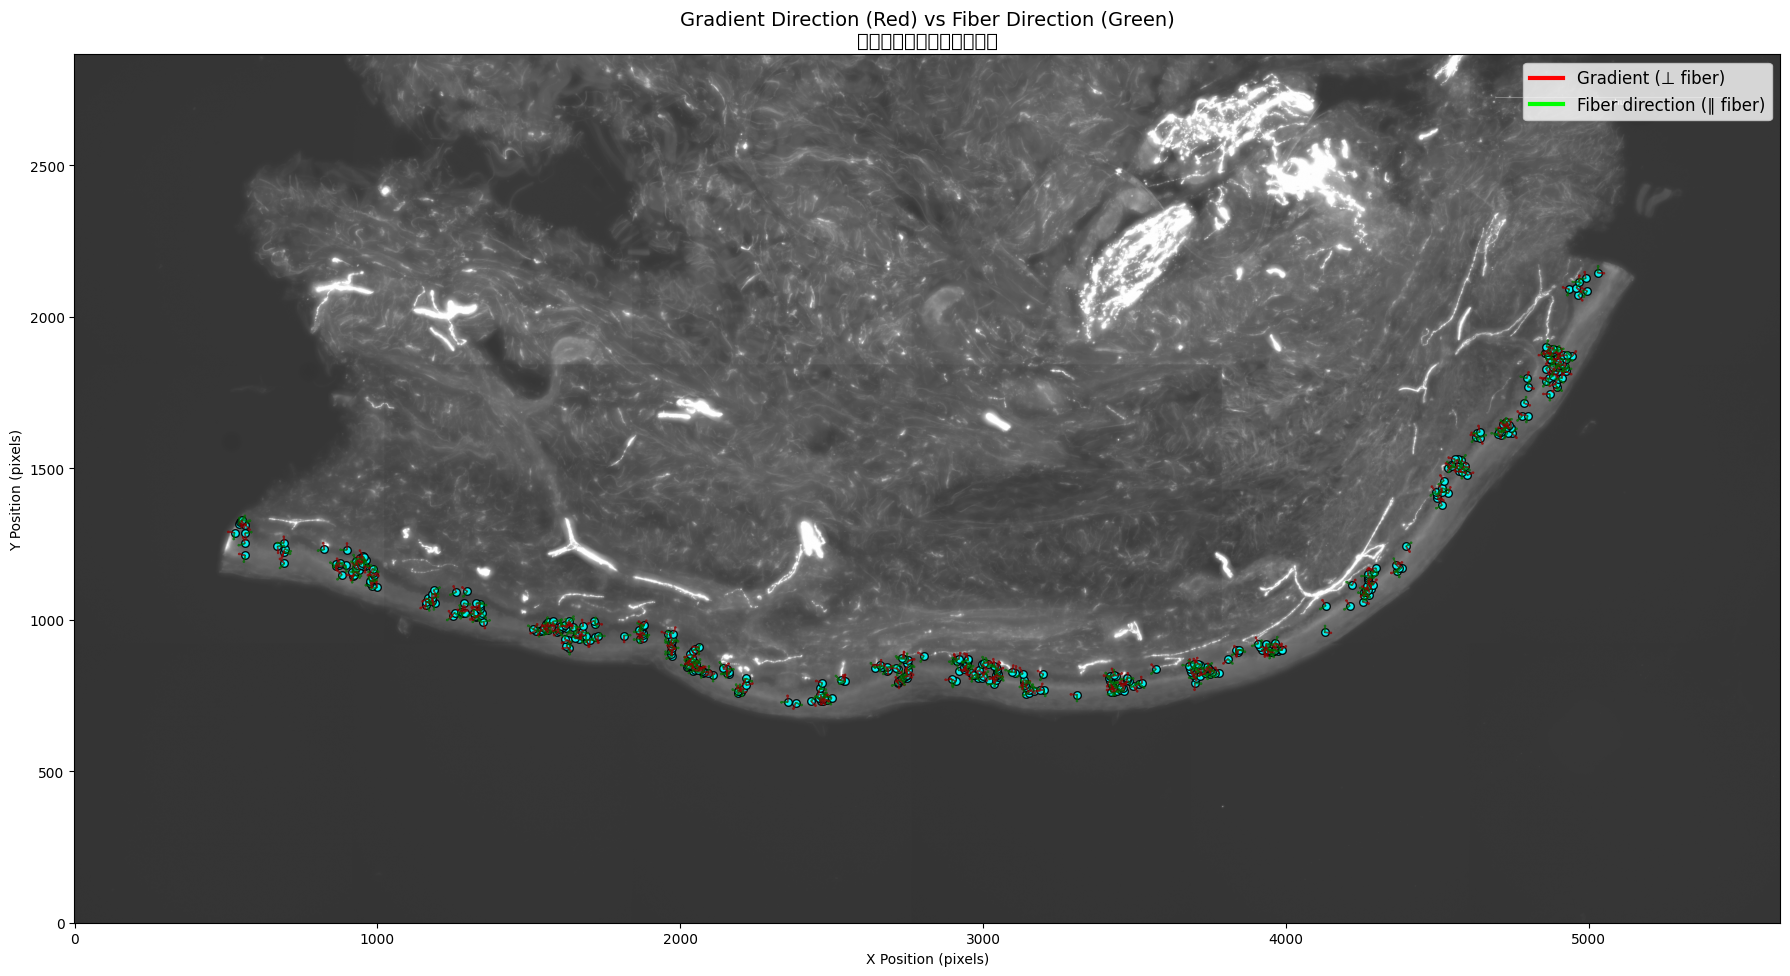

✓ 梯度方向 vs 纖維方向比較圖已儲存


In [49]:
# Visualization 3b: 梯度方向 vs 纖維方向比較
fig, ax = plt.subplots(1, 1, figsize=(18, 10))

ax.imshow(image, cmap='gray', alpha=0.8)

# 取得位置資料
pos_x = np.array([g['x'] for g in seed_gradients])
pos_y = np.array([g['y'] for g in seed_gradients])

# Draw seed points
ax.scatter(pos_x, pos_y, c='cyan', s=30, edgecolors='black', alpha=0.9, zorder=2)

# 箭頭長度
arrow_length = 20

for g in seed_gradients:
    x, y = g['x'], g['y']
    
    # 紅色：梯度方向（垂直於纖維）
    grad_dx = np.cos(g['grad_angle']) * arrow_length
    grad_dy = np.sin(g['grad_angle']) * arrow_length
    ax.arrow(x, y, grad_dx, grad_dy,
             head_width=6, head_length=4, 
             fc='red', ec='darkred', linewidth=1, alpha=0.7, zorder=3)
    
    # 綠色：纖維方向（沿著纖維）
    fiber_dx = np.cos(g['fiber_angle']) * arrow_length
    fiber_dy = np.sin(g['fiber_angle']) * arrow_length
    ax.arrow(x, y, fiber_dx, fiber_dy,
             head_width=6, head_length=4, 
             fc='lime', ec='darkgreen', linewidth=1, alpha=0.7, zorder=3)

# 圖例
from matplotlib.patches import FancyArrow
ax.plot([], [], color='red', linewidth=3, label='Gradient (⊥ fiber)')
ax.plot([], [], color='lime', linewidth=3, label='Fiber direction (∥ fiber)')
ax.legend(loc='upper right', fontsize=12)

ax.set_title('Gradient Direction (Red) vs Fiber Direction (Green)\n綠色箭頭應該沿著纖維走向', fontsize=14)
ax.set_xlabel('X Position (pixels)')
ax.set_ylabel('Y Position (pixels)')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('/Users/ponywen/projects/ienf_q/notebooks/03b_gradient_vs_fiber.png', dpi=150, bbox_inches='tight')
plt.show()

print('✓ 梯度方向 vs 纖維方向比較圖已儲存')

In [ ]:
smooth_image = cv2.GaussianBlur(image, (3,3), 2)
_, ax = plt.subplots(nrows=1,ncols=1,figsize=(18, 10))